<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv('Position_Salaries.csv')
dataset.head()


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [5]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=10)
X_poly = poly_reg.fit_transform(X)
poly_reg.fit(X_poly, y)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

[330378.78787879] [172421.91732358]


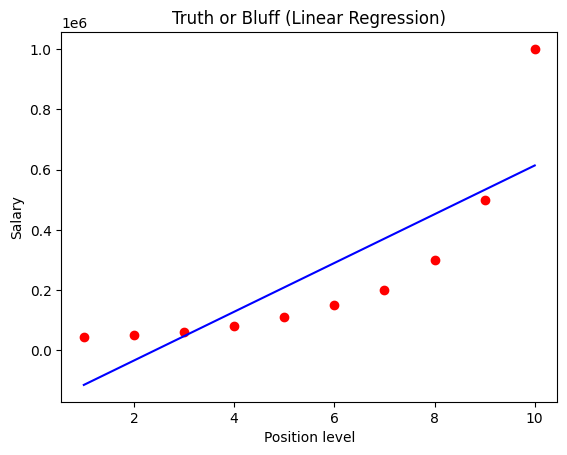

In [7]:
y_pred_lin = lin_reg.predict([[6.5]])
y_pred_poly = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print(y_pred_lin, y_pred_poly)

plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

/tmp/ipykernel_44527/2643874482.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


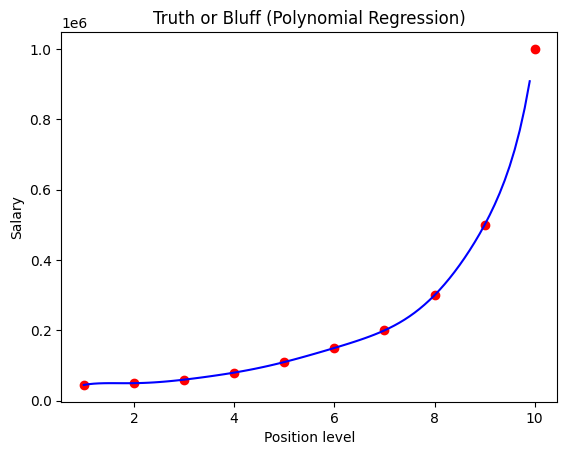

In [8]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color='blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

/tmp/ipykernel_44527/487214133.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
/tmp/ipykernel_44527/487214133.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
/tmp/ipykernel_44527/487214133.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
/tmp/ipykernel_44527/487214133.py:13: DeprecationWar

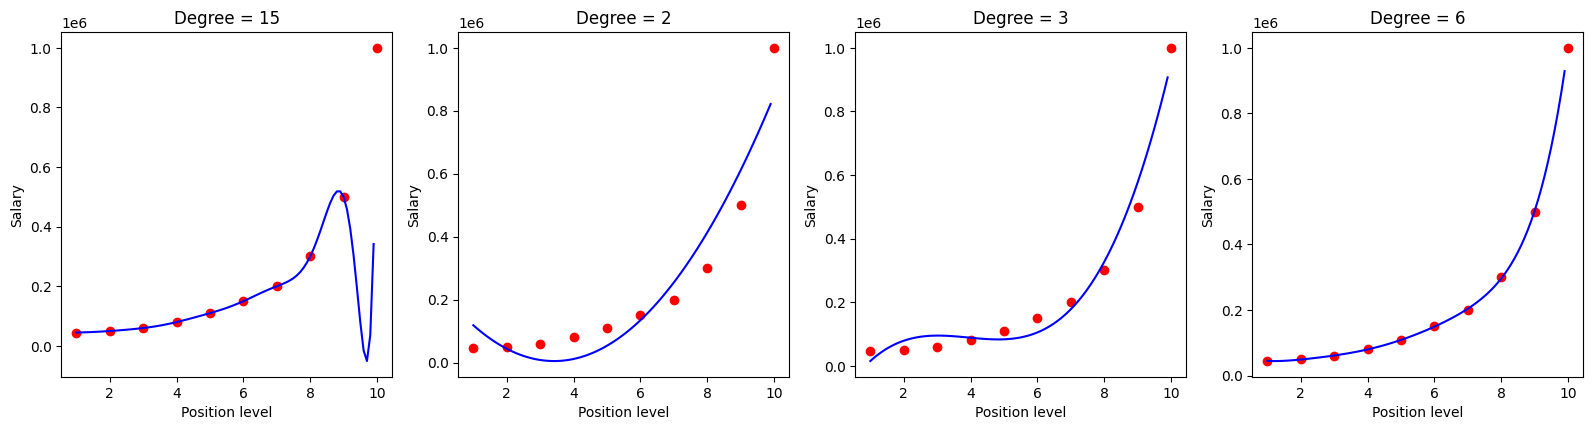

In [12]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [15,2,3,6]
plt.figure(figsize=(20, 8))

for i, degree in enumerate(degrees, 1):
    plt.subplot(2, 5, i)
    poly_reg = PolynomialFeatures(degree=degree)
    X_poly = poly_reg.fit_transform(X)
    lin_reg_2 = LinearRegression()
    lin_reg_2.fit(X_poly, y)

    X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1)
    plt.scatter(X, y, color='red')
    plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color='blue')
    plt.title(f'Degree = {degree}')
    plt.xlabel('Position level')
    plt.ylabel('Salary')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = [1, 2, 3, 4]

print("Результаты полиномиальной регрессии с проверкой на переобучение:")
print(f"{'Degree':<10} {'R² train':<12} {'R² test':<12} {'Разница':<12} {'RMSE test':<12} {'Признаков':<10}")

# Обучение моделей в цикле
for d in degrees:
    if d == 1:
        X_train_poly = X_train
        X_test_poly = X_test
    else:
        poly = PolynomialFeatures(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Предсказание и оценка на обучении и тесте
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    n_features = X_train_poly.shape[1]
    diff = r2_train - r2_test

    print(f"{d:<10} {r2_train:<12.4f} {r2_test:<12.4f} {diff:<12.4f} {rmse_test:<12.4f} {n_features:<10}")

print("\nПроверка на переобучение:")
for d in degrees:
    if d == 1:
        X_train_poly = X_train
        X_test_poly = X_test
    else:
        poly = PolynomialFeatures(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    r2_train = r2_score(y_train, model.predict(X_train_poly))
    r2_test = r2_score(y_test, model.predict(X_test_poly))
    diff = r2_train - r2_test

    if diff < 0.05:
        status = "Нет переобучения"
    elif diff < 0.1:
        status = "Слабое переобучение"
    else:
        status = "Сильное переобучение"

    print(f"Degree {d}: R² train={r2_train:.4f}, R² test={r2_test:.4f}, разница={diff:.4f} -> {status}")

Результаты полиномиальной регрессии с проверкой на переобучение:
Degree     R² train     R² test      Разница      RMSE test    Признаков 
1          0.6126       0.5758       0.0368       0.7456       8         
2          0.6853       0.6457       0.0396       0.6814       45        
3          0.7328       -2.5114      3.2442       2.1451       165       
4          0.7059       -79.1639     79.8698      10.2493      495       

Проверка на переобучение:
--------------------------------------------------
Degree 1: R² train=0.6126, R² test=0.5758, разница=0.0368 -> Нет переобучения
Degree 2: R² train=0.6853, R² test=0.6457, разница=0.0396 -> Нет переобучения
Degree 3: R² train=0.7328, R² test=-2.5114, разница=3.2442 -> Сильное переобучение
Degree 4: R² train=0.7059, R² test=-79.1639, разница=79.8698 -> Сильное переобучение


/tmp/ipykernel_54703/131274359.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X_single), max(X_single), 0.01).reshape(-1, 1)


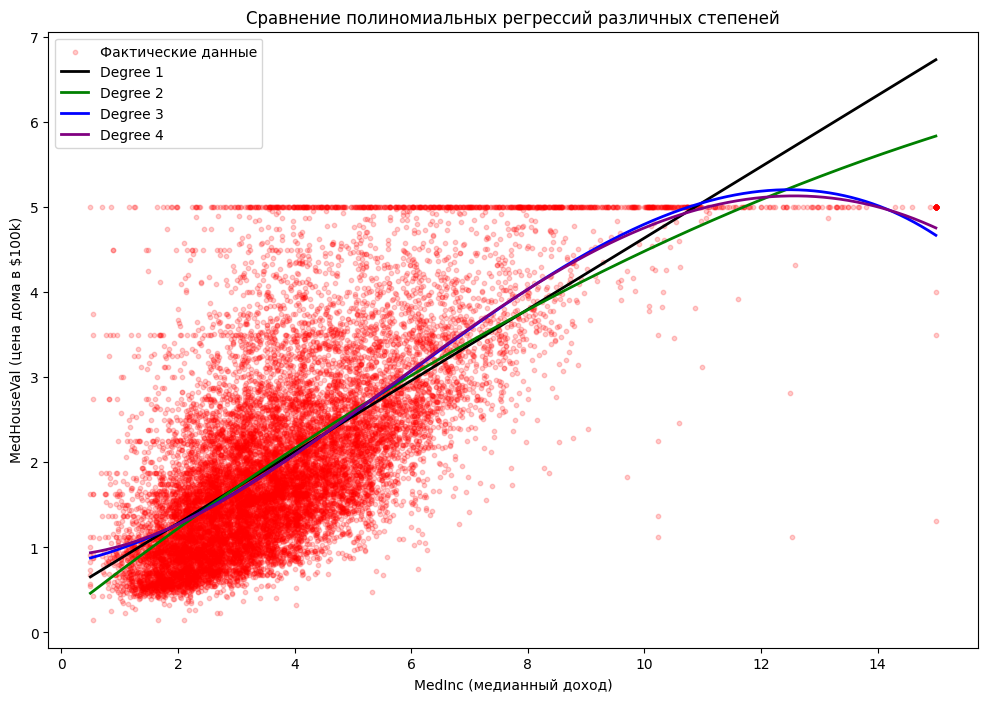

In [9]:
# Визуализация для признака MedInc (индекс 0)
X_single = X_train[:, 0].reshape(-1, 1)
y_single = y_train

X_grid = np.arange(min(X_single), max(X_single), 0.01).reshape(-1, 1)

plt.figure(figsize=(12, 8))
plt.scatter(X_single, y_single, color='red', alpha=0.2, s=10, label='Фактические данные')

# Цвета для разных степеней
colors = ['black', 'green', 'blue', 'purple']

for d, color in zip(degrees, colors):
    if d == 1:
        model = LinearRegression()
        model.fit(X_single, y_single)
        y_grid_pred = model.predict(X_grid)
    else:
        poly = PolynomialFeatures(degree=d)
        X_single_poly = poly.fit_transform(X_single)
        model = LinearRegression()
        model.fit(X_single_poly, y_single)
        y_grid_pred = model.predict(poly.transform(X_grid))

    plt.plot(X_grid, y_grid_pred, color=color, linewidth=2, label=f'Degree {d}')

plt.title('Сравнение полиномиальных регрессий различных степеней')
plt.xlabel('MedInc (медианный доход)')
plt.ylabel('MedHouseVal (цена дома в $100k)')
plt.legend()
plt.show()